In [1]:
import os
import sys
import shutil
os.environ['TOKENIZERS_PARALLELISM'] = "False"

import torch
import pandas as pd
import numpy as np
import decord
import json
from IPython.display import display, Markdown, Latex
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"
import PIL.Image
from glob import glob
from natsort import natsorted

from torch.utils.data import Dataset, DataLoader
from easydict import EasyDict as edict
import numpy as np
import json

import shared.utils as su
from utils.video import read_frames_decord
from utils.model import transform_pixel_values
from torchvision.transforms.v2 import (
    ToPILImage,
)
from models.modeling_encoders import AutoEncoder
from notebooks.eval_care_retrieval import load_model, load_data

Failed to import Qwen2_5_VLModel, Qwen2_5_VLForConditionalGeneration.


In [30]:
# Load data
dataset = 'ssv2'
df = load_data(dataset)
df = df.drop_duplicates(subset=['id', 'text_id']).reset_index(drop=True)

# Chiral IDs
chiral_triplet_ids = df.chiral_triplet_id.unique()

df.shape

Number of rows:  1430
Sample row: 
{
    "id": 69703,
    "label": "moving pen up",
    "template": "Moving [something] up",
    "placeholders": "['pen']",
    "target": 114,
    "chiral_label": 0.0,
    "chiral_triplet_id": "3f20f09b",
    "noun": "['something']",
    "text_id": "3f20f09b_0.0",
    "video_path": "/scratch/shared/beegfs/piyush/datasets/SSv2/20bn-something-something-v2/69703.webm"
}


(1430, 10)

In [31]:
embed_dirs = {
    # "Base": "/work/piyush/pretrained_checkpoints/Tarsier-7b/embs",
    # "TARA": "/work/piyush/experiments/CaRe/Tarsier-7b/final-10112025/nli_9000+ego_1000+subj_replaced-seed_42/embs"
    "Base": "/work/piyush/pretrained_checkpoints/Tarsier2-7b-0115/embs/",
    "TARA": "/work/piyush/experiments/CaRe/Tarsier2-7b-0115/covr/chiral10k-covr10k/merged_checkpoint/embs/"
}
video_feat = {}
texts_feat = {}
for model_name in embed_dirs:
    video_feat[model_name] = torch.load(f"{embed_dirs[model_name]}/video_feat-{dataset}.pt")
    texts_feat[model_name] = torch.load(f"{embed_dirs[model_name]}/texts_feat-{dataset}.pt")
len(texts_feat)

2

In [32]:
df.template.unique()

array(['Moving [something] up', 'Folding [something]',
       'Unfolding [something]', 'Moving [something] down',
       'Taking [one of many similar things on the table]',
       'Pushing [something] from right to left',
       'Pushing [something] from left to right', 'Closing [something]',
       'Putting [something similar to other things that are already on the table]',
       'Moving [something] and [something] away from each other',
       'Moving [something] and [something] closer to each other',
       'Opening [something]', 'Pulling [something] from right to left',
       'Moving [something] towards the camera',
       'Turning the camera right while filming [something]',
       'Moving [something] away from the camera',
       'Pulling [something] from left to right',
       'Turning the camera left while filming [something]',
       'Turning the camera downwards while filming [something]',
       'Approaching [something] with your camera',
       'Turning the camera upwards

In [33]:
# df[df.template == "Moving [something] up"].chiral_triplet_id.iloc[0]
# df[df.template == 'someone is dressing'].chiral_triplet_id.iloc[0]
# template = 'someone is standing up from somewhere'
template = 'put-down plate'

df[df.template == template].chiral_triplet_id.iloc[0]

IndexError: single positional indexer is out-of-bounds

**With text embeddings**

torch.Size([60, 3584])
[-0.30225633 -0.53686404]
[-0.14448632 -0.60592534]
----------------------------------------------------------------------------------------------------
torch.Size([60, 3584])
[ 0.51154013 -0.12561884]
[-0.39898515 -0.10799444]
----------------------------------------------------------------------------------------------------


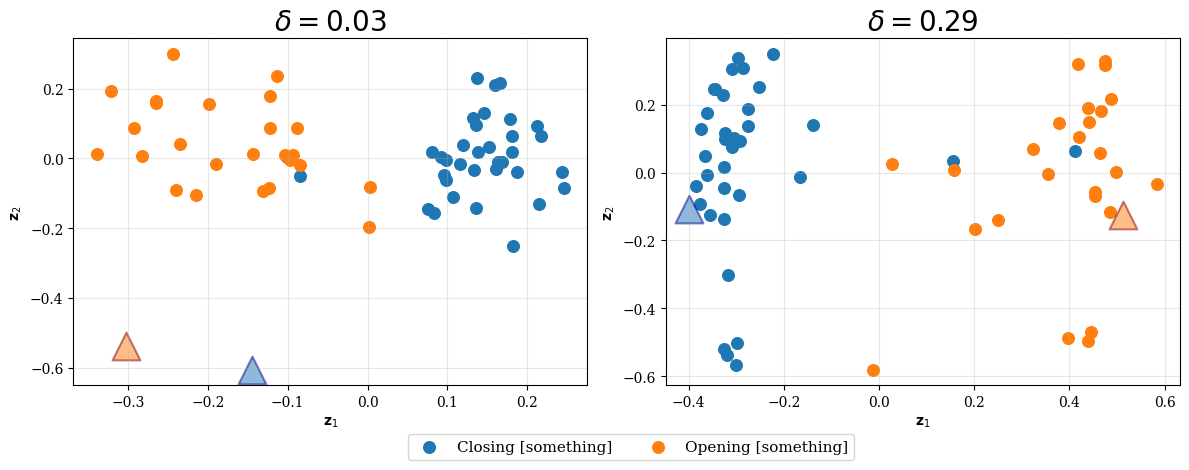

In [36]:
# Pick a chiral action
cid = np.random.choice(chiral_triplet_ids)

# cid = '3f20f09b'
# cid = '7f9dfd30'
# cid = 'e3c2c932'
# cid = 'ecff8160'

# cid = chiral_triplet_ids[15]
# cid = "b58b2f93"
text_id_neg = f"{cid}_0.0"
text_id_pos = f"{cid}_1.0"
subdf = df[df.text_id.isin([text_id_neg, text_id_pos])]
ids = subdf.id.tolist()
class_names = subdf.template.unique()

n_models = len(embed_dirs)
model_names = list(embed_dirs)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 4.5))
method = 'pca'
# method = 'tsne'
save = False

handles, labels = None, None  # To store legend handles/labels


# Compute delta
delta = {}
cosine_sim = lambda x, y: torch.nn.functional.cosine_similarity(x, y).mean()
euclid_dis = lambda x, y: torch.cdist(x.unsqueeze(0), y).mean()
idx_pos = np.where(subdf.chiral_label == 1.0)[0]
idx_neg = np.where(subdf.chiral_label == 0.0)[0]
dist_fn = cosine_sim
# dist_fn = euclid_dis
for j in range(2):
    model_name = model_names[j]

    zv_ = torch.stack([video_feat[model_name][k] for k in ids])
    zt_pos = texts_feat[model_name][f"{cid}_1.0"]
    zt_neg = texts_feat[model_name][f"{cid}_0.0"]
    zt_ = torch.stack([zt_pos, zt_neg])

    s_pos = (dist_fn(zt_pos, zv_[idx_pos]) - dist_fn(zt_pos, zv_[idx_neg])).item()
    s_neg = (dist_fn(zt_neg, zv_[idx_neg]) - dist_fn(zt_neg, zv_[idx_pos])).item()
    s = (s_pos + s_neg) / 2.
    # print(model_name, s)
    delta[model_name] = np.round(s, 2)


for j, ax in enumerate(axes):
    model_name = model_names[j]
    ax.grid(alpha=0.3)
    ax.set_xlabel("$\\mathbf{z}_{1}$")
    ax.set_ylabel("$\\mathbf{z}_{2}$")
    # if j == 0:
    #     ax.set_title("Base Model (Tarsier-7B)", fontsize=13)
    # else:
    #     ax.set_title("TARA (Ours)", fontsize=13)
    # ax.set_title(model_name, fontsize=13)
    zv_ = torch.stack([video_feat[model_name][k] for k in ids])
    print(zv_.shape)

    zt_pos = texts_feat[model_name][f"{cid}_1.0"]
    zt_neg = texts_feat[model_name][f"{cid}_0.0"]
    z = torch.cat([zv_, zt_pos[None], zt_neg[None]])
    tsne = su.visualize.reduce_dim(z, method=method)
    tsne_v = tsne[:-2]
    tsne_tpos = tsne[-2]
    tsne_tneg = tsne[-1]
    print(tsne_tpos)
    print(tsne_tneg)

    chiral_labels = [0.0, 1.0]
    colors = ['tab:blue', 'tab:orange']
    edgecolor = ['darkblue', 'maroon']
    for p, l in enumerate(chiral_labels):
        idx = np.where(subdf.chiral_label == l)[0]
        ax.scatter(tsne_v[idx, 0], tsne_v[idx, 1], label=class_names[p], s=70, color=colors[p])

        s = 400
        if l == 1.0:
            ax.scatter(tsne_tpos[0], tsne_tpos[1], marker='^', s=s, color=colors[p], edgecolor=edgecolor[p], alpha=0.5, linewidths=1.5)
        else:
            ax.scatter(tsne_tneg[0], tsne_tneg[1], marker='^', s=s, color=colors[p], edgecolor=edgecolor[p], alpha=0.5, linewidths=1.5)
    
    # for p, l in enumerate(class_names):
    #     idx = np.where(subdf.template == class_names[p])[0]
    #     ax.scatter(tsne_v[idx, 0], tsne_v[idx, 1], label=class_names[p], s=50)
    # ax.scatter(tsne_tpos[0], tsne_tpos[1], marker='x', s=120, color='tab:blue')
    # ax.scatter(tsne_tneg[0], tsne_tneg[1], marker='x', s=120, color='tab:orange')
    
    # Capture handles and labels from the first subplot
    if handles is None:
        handles, labels = ax.get_legend_handles_labels()

    ax.set_title("$\delta = %s$" % delta[model_name], fontsize=20)
    print("-" * 100)

# Annotate
# ax.annotate('Video', xy=(tsne_v[-1, 0], tsne_v[-1, 1]), 
#             xytext=(20, 10), textcoords='offset points',
#             arrowprops=dict(arrowstyle='->', color='gray'),
#             fontsize=10)
# ax.annotate('Video', xy=(tsne_v[140, 0], tsne_v[140, 1]), 
#             xytext=(20, 15), textcoords='offset points',
#             arrowprops=dict(arrowstyle='->', color='gray'),
#             fontsize=20)

# ax.annotate('Text', xy=(tsne_tpos[0], tsne_tpos[1]), 
#             xytext=(-5, -30), textcoords='offset points',
#             arrowprops=dict(arrowstyle='->', color='gray'),
#             fontsize=10)


# Create a single legend below the plots, centered, single column
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.53, 0.04), 
           ncol=2, frameon=True, fontsize=11)

plt.tight_layout()
# plt.subplots_adjust(bottom=0.25)  # Make room for the legend at the bottom
# plt.savefig("../figures/tsne-take-put-v2.pdf", bbox_inches='tight')
if save:
    plt.savefig(f"../figures/{method}-{cid}-v2.pdf", bbox_inches='tight')
plt.show()

In [13]:
cosine_sim = lambda x, y: torch.nn.functional.cosine_similarity(x, y).mean()
euclid_dis = lambda x, y: torch.cdist(x.unsqueeze(0), y).mean()

idx_pos = np.where(subdf.chiral_label == 1.0)[0]
idx_neg = np.where(subdf.chiral_label == 0.0)[0]

dist_fn = cosine_sim
# dist_fn = euclid_dis

for j in range(2):
    model_name = model_names[j]

    zv_ = torch.stack([video_feat[model_name][k] for k in ids])
    zt_pos = texts_feat[model_name][f"{cid}_1.0"]
    zt_neg = texts_feat[model_name][f"{cid}_0.0"]
    zt_ = torch.stack([zt_pos, zt_neg])

    s_pos = (dist_fn(zt_pos, zv_[idx_pos]) - dist_fn(zt_pos, zv_[idx_neg])).item()
    s_neg = (dist_fn(zt_neg, zv_[idx_neg]) - dist_fn(zt_neg, zv_[idx_pos])).item()
    s = (s_pos + s_neg) / 2.
    print(model_name, s)

Base 0.009812235832214355
TARA 0.09355678409337997


### Old code

torch.Size([71, 3584])
torch.Size([71, 3584])


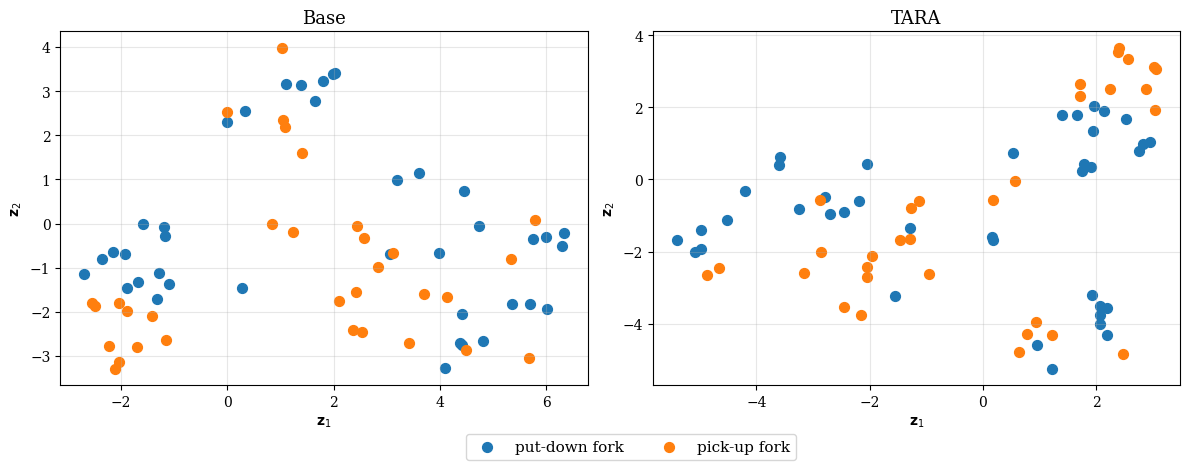

In [111]:
# Pick a chiral action
# cid = np.random.choice(chiral_triplet_ids)
cid = '3f20f09b'

# cid = chiral_triplet_ids[1]
# cid = chiral_triplet_ids[11]
# cid = "b58b2f93"
text_id_neg = f"{cid}_0.0"
text_id_pos = f"{cid}_1.0"
subdf = df[df.text_id.isin([text_id_neg, text_id_pos])]
ids = subdf.id.tolist()
class_names = subdf.template.unique()
# method = 'pca'
method = "tsne"
save = False

n_models = len(embed_dirs)
model_names = list(embed_dirs)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 4.5))

handles, labels = None, None  # To store legend handles/labels

for j, ax in enumerate(axes):
    model_name = model_names[j]
    ax.grid(alpha=0.3)
    ax.set_xlabel("$\\mathbf{z}_{1}$")
    ax.set_ylabel("$\\mathbf{z}_{2}$")
    ax.set_title(model_name, fontsize=13)
    zv_ = torch.stack([video_feat[model_name][k] for k in ids])
    print(zv_.shape)
    
    tsne_ = su.visualize.reduce_dim(zv_, method=method)
    for l in class_names:
        idx = np.where(subdf.template == l)[0]
        ax.scatter(tsne_[idx, 0], tsne_[idx, 1], label=l, s=50)
    
    # Capture handles and labels from the first subplot
    if handles is None:
        handles, labels = ax.get_legend_handles_labels()

# Create a single legend below the plots, centered, single column
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.53, 0.04), 
           ncol=2, frameon=True, fontsize=11)

plt.tight_layout()
# plt.subplots_adjust(bottom=0.25)  # Make room for the legend at the bottom
# plt.savefig("../figures/tsne-take-put-v1.pdf", bbox_inches='tight')
plt.show()